<a href="https://colab.research.google.com/github/RientArlCroud/Challenge-4-telecom-X-2-an-lisis-de-datos/blob/main/Challenge_4_an%C3%A1lisis_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge 3 Análisis de datos, empresa de telecomunicaciones Telecom X

proceso de modelado para identificar posibles cancelaciones del servicio.


In [4]:
import pandas as pd

Lectura de datos

In [5]:
df = pd.read_csv('/content/telecom.csv')

In [6]:
df

,customer_id,churn,customer_gender,customer_senior_citizen,customer_partner,customer_dependents,customer_tenure,phone_phone_service,phone_multiple_lines,internet_internet_service,...,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total,cuentas_diarias,tenure_group,charges_monthly_group
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667,"(6, 12]","(54, 66]"
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667,"(6, 12]","(54, 66]"
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333,"(0, 6]","(66, 78]"
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667,"(12, 24]","(90, 102]"
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667,"(0, 6]","(78, 90]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,One year,No,Mailed check,55.15,742.90,1.838333,"(12, 24]","(54, 66]"
7028,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667,"(12, 24]","(78, 90]"
7029,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667,"(0, 6]","(42, 54]"
7030,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667,"(48, 72]","(66, 78]"


Retiro de columnas innecesarias

In [7]:
df.drop(columns=['customer_id','cuentas_diarias', 'tenure_group', 'charges_monthly_group'], axis=1, inplace=True)

In [8]:
df

,churn,customer_gender,customer_senior_citizen,customer_partner,customer_dependents,customer_tenure,phone_phone_service,phone_multiple_lines,internet_internet_service,internet_online_security,internet_online_backup,internet_device_protection,internet_tech_support,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,No,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7028,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7029,No,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7030,No,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


Selección de variables explicativas y variable dependiente (objetivo)

In [9]:
X = df.drop(columns=['churn'], axis=1)
y = df['churn']

In [10]:
X

,customer_gender,customer_senior_citizen,customer_partner,customer_dependents,customer_tenure,phone_phone_service,phone_multiple_lines,internet_internet_service,internet_online_security,internet_online_backup,internet_device_protection,internet_tech_support,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Female,0,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7028,Male,0,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7029,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7030,Male,0,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [11]:
y

,churn
0,No
1,No
2,Yes
3,Yes
4,Yes
...,...
7027,No
7028,Yes
7029,No
7030,No


Proceso de encoding para las variables explicativas y la variable objetivo

In [12]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [13]:
columnas = X.columns
columnas

Index(['customer_gender', 'customer_senior_citizen', 'customer_partner',
       'customer_dependents', 'customer_tenure', 'phone_phone_service',
       'phone_multiple_lines', 'internet_internet_service',
       'internet_online_security', 'internet_online_backup',
       'internet_device_protection', 'internet_tech_support',
       'internet_streaming_tv', 'internet_streaming_movies',
       'account_contract', 'account_paperless_billing',
       'account_payment_method', 'account_charges_monthly',
       'account_charges_total'],
      dtype='object')

In [14]:
one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), ['customer_gender', 'customer_partner', 'customer_dependents',
                                       'phone_phone_service', 'phone_multiple_lines', 'internet_internet_service',
                                       'internet_online_security', 'internet_online_backup', 'internet_device_protection',
                                       'internet_tech_support', 'internet_streaming_tv', 'internet_streaming_movies', 'account_contract',
                                       'account_paperless_billing', 'account_payment_method']),
    remainder = 'passthrough',
    sparse_threshold = 0,
    verbose_feature_names_out = True
)

In [15]:
X = one_hot.fit_transform(X)

In [16]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__customer_gender_Male',
       'onehotencoder__customer_partner_Yes',
       'onehotencoder__customer_dependents_Yes',
       'onehotencoder__phone_phone_service_Yes',
       'onehotencoder__phone_multiple_lines_No',
       'onehotencoder__phone_multiple_lines_No phone service',
       'onehotencoder__phone_multiple_lines_Yes',
       'onehotencoder__internet_internet_service_DSL',
       'onehotencoder__internet_internet_service_Fiber optic',
       'onehotencoder__internet_internet_service_No',
       'onehotencoder__internet_online_security_No',
       'onehotencoder__internet_online_security_No internet service',
       'onehotencoder__internet_online_security_Yes',
       'onehotencoder__internet_online_backup_No',
       'onehotencoder__internet_online_backup_No internet service',
       'onehotencoder__internet_online_backup_Yes',
       'onehotencoder__internet_device_protection_No',
       'onehotencoder__internet_device_protection_No internet service',
 

In [17]:
X

array([[0.00000e+00, 1.00000e+00, 1.00000e+00, ..., 9.00000e+00,
        6.56000e+01, 5.93300e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 9.00000e+00,
        5.99000e+01, 5.42400e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 4.00000e+00,
        7.39000e+01, 2.80850e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 2.00000e+00,
        5.03000e+01, 9.27500e+01],
       [1.00000e+00, 1.00000e+00, 1.00000e+00, ..., 6.70000e+01,
        6.78500e+01, 4.62765e+03],
       [1.00000e+00, 1.00000e+00, 1.00000e+00, ..., 6.30000e+01,
        5.90000e+01, 3.70760e+03]])

In [18]:
X_DF = pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas))

In [19]:
X_DF

,onehotencoder__customer_gender_Male,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phone_service_Yes,onehotencoder__phone_multiple_lines_No,onehotencoder__phone_multiple_lines_No phone service,onehotencoder__phone_multiple_lines_Yes,onehotencoder__internet_internet_service_DSL,onehotencoder__internet_internet_service_Fiber optic,onehotencoder__internet_internet_service_No,...,onehotencoder__account_contract_Two year,onehotencoder__account_paperless_billing_Yes,onehotencoder__account_payment_method_Bank transfer (automatic),onehotencoder__account_payment_method_Credit card (automatic),onehotencoder__account_payment_method_Electronic check,onehotencoder__account_payment_method_Mailed check,remainder__customer_senior_citizen,remainder__customer_tenure,remainder__account_charges_monthly,remainder__account_charges_total
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9.0,65.60,593.30
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,59.90,542.40
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.0,73.90,280.85
3,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,13.0,98.00,1237.85
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,3.0,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,55.15,742.90
7028,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,22.0,85.10,1873.70
7029,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,50.30,92.75
7030,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,67.0,67.85,4627.65


In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
label_encoder = LabelEncoder()

In [22]:
y = label_encoder.fit_transform(y)

In [23]:
y

array([0, 0, 1, ..., 0, 0, 0])

Observando si existe desbalance en la variable objetivo

In [24]:
df['churn'].value_counts()

,count
churn,
No,5163
Yes,1869


In [25]:
df['churn'].value_counts(normalize=True)

,proportion
churn,
No,0.734215
Yes,0.265785


Posible balanceo de datos

In [26]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

In [27]:
oversampling = SMOTE()
undersampling = NearMiss()

In [28]:
X_balanceada_OS, y_balanceada_OS = oversampling.fit_resample(X, y)

In [29]:
pd.Series(y_balanceada_OS).value_counts()

,count
0,5163
1,5163


In [30]:
X_balanceada_US, y_balanceada_US = undersampling.fit_resample(X, y)

In [31]:
pd.Series(y_balanceada_US).value_counts()

,count
0,1869
1,1869


In [32]:
import matplotlib.pyplot as plt

(array([2709., 1228.,  671.,  508.,  454.,  412.,  395.,  310.,  223.,
         122.]),
 array([  18.8,  885.4, 1752. , 2618.6, 3485.2, 4351.8, 5218.4, 6085. ,
        6951.6, 7818.2, 8684.8]),
 <BarContainer object of 10 artists>)

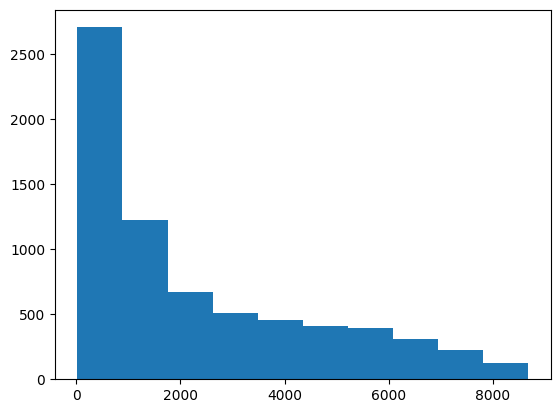

In [33]:
plt.hist(df['account_charges_total'])

In [34]:
df_final = pd.DataFrame(X, columns=one_hot.get_feature_names_out(columnas))
df_final['Churn'] = y
df_final

,onehotencoder__customer_gender_Male,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phone_service_Yes,onehotencoder__phone_multiple_lines_No,onehotencoder__phone_multiple_lines_No phone service,onehotencoder__phone_multiple_lines_Yes,onehotencoder__internet_internet_service_DSL,onehotencoder__internet_internet_service_Fiber optic,onehotencoder__internet_internet_service_No,...,onehotencoder__account_paperless_billing_Yes,onehotencoder__account_payment_method_Bank transfer (automatic),onehotencoder__account_payment_method_Credit card (automatic),onehotencoder__account_payment_method_Electronic check,onehotencoder__account_payment_method_Mailed check,remainder__customer_senior_citizen,remainder__customer_tenure,remainder__account_charges_monthly,remainder__account_charges_total,Churn
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,9.0,65.60,593.30,0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,9.0,59.90,542.40,0
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,4.0,73.90,280.85,1
3,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,13.0,98.00,1237.85,1
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,3.0,83.90,267.40,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,13.0,55.15,742.90,0
7028,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,22.0,85.10,1873.70,1
7029,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,2.0,50.30,92.75,0
7030,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,67.0,67.85,4627.65,0


Análisis de correlación

In [35]:
df_final.corr()

,onehotencoder__customer_gender_Male,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phone_service_Yes,onehotencoder__phone_multiple_lines_No,onehotencoder__phone_multiple_lines_No phone service,onehotencoder__phone_multiple_lines_Yes,onehotencoder__internet_internet_service_DSL,onehotencoder__internet_internet_service_Fiber optic,onehotencoder__internet_internet_service_No,...,onehotencoder__account_paperless_billing_Yes,onehotencoder__account_payment_method_Bank transfer (automatic),onehotencoder__account_payment_method_Credit card (automatic),onehotencoder__account_payment_method_Electronic check,onehotencoder__account_payment_method_Mailed check,remainder__customer_senior_citizen,remainder__customer_tenure,remainder__account_charges_monthly,remainder__account_charges_total,Churn
onehotencoder__customer_gender_Male,1.000000,-0.001379,0.010349,-0.007515,0.004335,0.007515,-0.008883,0.007584,-0.011189,0.004745,...,-0.011902,-0.015973,0.001632,0.000844,0.013199,-0.001819,0.005285,-0.013779,0.000048,-0.008545
onehotencoder__customer_partner_Yes,-0.001379,1.000000,0.452269,0.018397,-0.130028,-0.018397,0.142561,-0.001043,0.001235,-0.000286,...,-0.013957,0.111406,0.082327,-0.083207,-0.096948,0.016957,0.381912,0.097825,0.319072,-0.149982
onehotencoder__customer_dependents_Yes,0.010349,0.452269,1.000000,-0.001078,0.023388,0.001078,-0.024307,0.051593,-0.164101,0.138383,...,-0.110131,0.052369,0.061134,-0.149274,0.056448,-0.210550,0.163386,-0.112343,0.064653,-0.163128
onehotencoder__phone_phone_service_Yes,-0.007515,0.018397,-0.001078,1.000000,0.315218,-1.000000,0.279530,-0.452255,0.290183,0.171817,...,0.016696,0.008271,-0.006916,0.002747,-0.004463,0.008392,0.007877,0.248033,0.113008,0.011691
onehotencoder__phone_multiple_lines_No,0.004335,-0.130028,0.023388,0.315218,1.000000,-0.315218,-0.823076,-0.069515,-0.190531,0.309984,...,-0.151974,-0.069663,-0.063712,-0.080990,0.222395,-0.136377,-0.323891,-0.338514,-0.396765,-0.032654
onehotencoder__phone_multiple_lines_No phone service,0.007515,-0.018397,0.001078,-1.000000,-0.315218,1.000000,-0.279530,0.452255,-0.290183,-0.171817,...,-0.016696,-0.008271,0.006916,-0.002747,0.004463,-0.008392,-0.007877,-0.248033,-0.113008,-0.011691
onehotencoder__phone_multiple_lines_Yes,-0.008883,0.142561,-0.024307,0.279530,-0.823076,-0.279530,1.000000,-0.200318,0.366420,-0.210794,...,0.163746,0.075429,0.060319,0.083583,-0.227672,0.142996,0.332399,0.490912,0.469042,0.040033
onehotencoder__internet_internet_service_DSL,0.007584,-0.001043,0.051593,-0.452255,-0.069515,0.452255,-0.200318,1.000000,-0.641636,-0.379912,...,-0.063390,0.024760,0.051222,-0.104293,0.042754,-0.108276,0.013786,-0.161368,-0.052190,-0.124141
onehotencoder__internet_internet_service_Fiber optic,-0.011189,0.001235,-0.164101,0.290183,-0.190531,-0.290183,0.366420,-0.641636,1.000000,-0.465736,...,0.326470,-0.022779,-0.050552,0.335763,-0.305984,0.254923,0.017930,0.787195,0.360769,0.307463
onehotencoder__internet_internet_service_No,0.004745,-0.000286,0.138383,0.171817,0.309984,-0.171817,-0.210794,-0.379912,-0.465736,1.000000,...,-0.320592,-0.001094,0.001870,-0.284608,0.319694,-0.182519,-0.037529,-0.763191,-0.374878,-0.227578


Análisis dirigido

In [36]:
import seaborn as sns

<Axes: xlabel='Churn', ylabel='remainder__customer_tenure'>

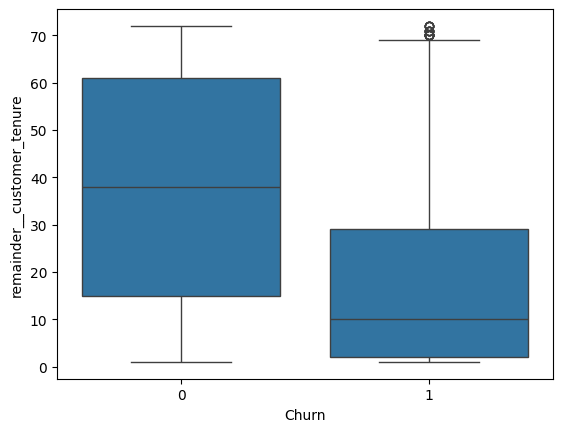

In [37]:
sns.boxplot(data=df_final, x='Churn', y='remainder__customer_tenure')

<Axes: xlabel='Churn', ylabel='remainder__account_charges_total'>

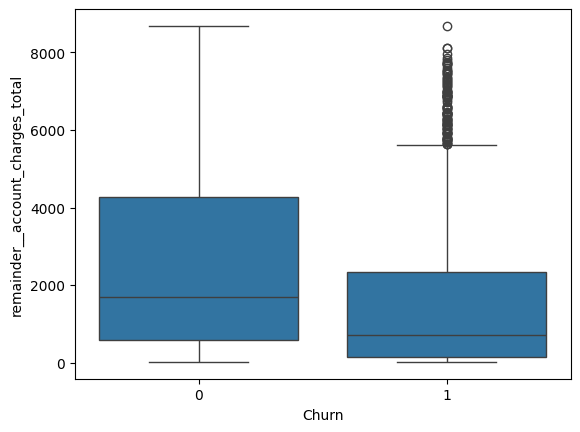

In [38]:
sns.boxplot(data=df_final, x='Churn', y='remainder__account_charges_total')

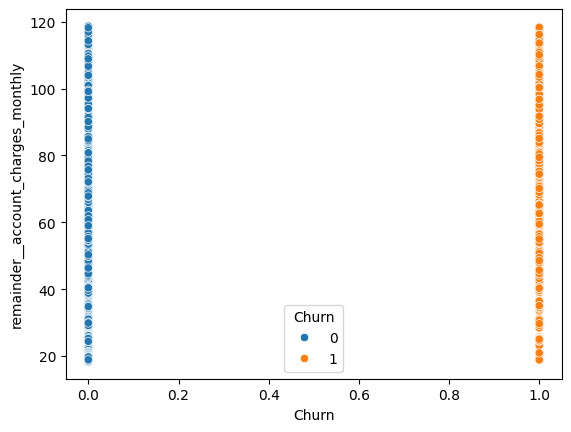

In [39]:
sns.scatterplot(data = df_final, x='Churn', y='remainder__account_charges_monthly', hue='Churn');

Separación de los Datos

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_DF, y, test_size=0.3, stratify = y, random_state=30)

## Creación de modelos

In [42]:
pd.DataFrame(y_train).value_counts(normalize=True)

,proportion
0,
0,0.734254
1,0.265746


In [43]:
pd.DataFrame(y_test).value_counts(normalize=True)

,proportion
0,
0,0.734123
1,0.265877


## Primer modelo: Baseline o Dummy

In [44]:
from sklearn.dummy import DummyClassifier

In [45]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [46]:
y_predicho = dummy.predict(X_test)

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [48]:
matriz_confusion_dummy = confusion_matrix(y_test, y_predicho)
print(matriz_confusion_dummy)

[[1549    0]
 [ 561    0]]


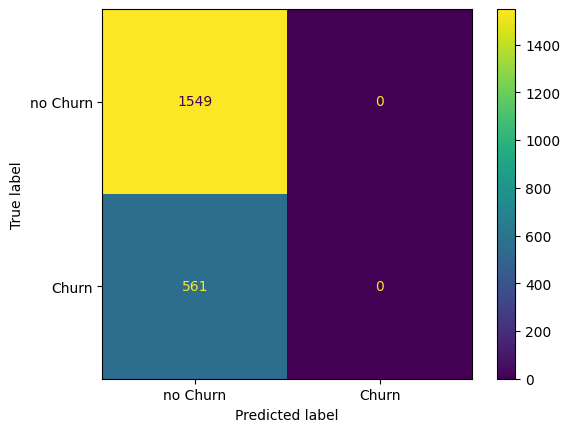

In [49]:
visualizacion_dummy = ConfusionMatrixDisplay(
    confusion_matrix = matriz_confusion_dummy,
    display_labels = ['no Churn' , 'Churn']
)
visualizacion_dummy.plot()

In [50]:
print(classification_report(y_test, y_predicho))

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1549
           1       0.00      0.00      0.00       561

    accuracy                           0.73      2110
   macro avg       0.37      0.50      0.42      2110
weighted avg       0.54      0.73      0.62      2110



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Segundo modelo: Regresión logística

Debemos escalar algunos de los atributos para que funcione mejor este modelo

In [51]:
X_train_scaled = X_train.copy()

In [52]:
X_test_scaled = X_test.copy()

In [53]:
columnas_continuas = [
    'remainder__customer_tenure',
    'remainder__account_charges_monthly',
    'remainder__account_charges_total'
]

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
scaler = StandardScaler()

In [56]:
scaler.fit(X_train_scaled[columnas_continuas])

StandardScaler()

In [57]:
X_train_scaled[columnas_continuas] = scaler.transform(X_train_scaled[columnas_continuas])

In [58]:
X_test_scaled[columnas_continuas] = scaler.transform(X_test_scaled[columnas_continuas])

In [59]:
from sklearn.linear_model import LogisticRegression

In [60]:
modelo_log = LogisticRegression(max_iter=1000)

In [61]:
modelo_log.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [62]:
y_pred_log = modelo_log.predict(X_test_scaled)

In [63]:
matriz_confusion_log = confusion_matrix(y_test, y_pred_log)
print(matriz_confusion_log)

[[1403  146]
 [ 268  293]]


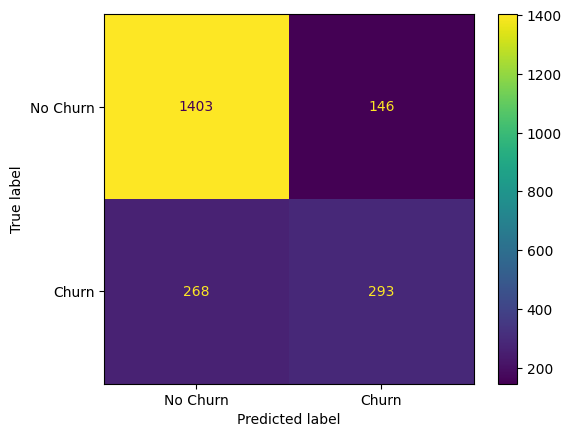

In [64]:
visualizacion_log = ConfusionMatrixDisplay(
    confusion_matrix = matriz_confusion_log,
    display_labels = ['No Churn' , 'Churn']
)
visualizacion_log.plot()

In [65]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1549
           1       0.67      0.52      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.71      0.73      2110
weighted avg       0.79      0.80      0.80      2110



## Tercer Modelo: Regresión logistica con Normalización aplicando SMOTE

In [66]:
X_train_res, y_train_res = oversampling.fit_resample(X_train_scaled, y_train)

In [68]:
modelo_log_SMOTE = LogisticRegression(max_iter=1000)
modelo_log_SMOTE.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=1000)

In [72]:
y_pred_SMOTE = modelo_log_SMOTE.predict(X_test_scaled)

In [73]:
matriz_confusion_SMOTE = confusion_matrix(y_test, y_pred_SMOTE)
print(matriz_confusion_SMOTE)

[[1158  391]
 [ 122  439]]


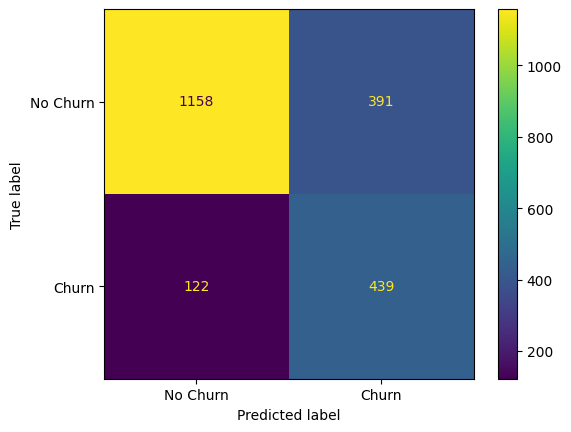

In [74]:
visualizacion_SMOTE = ConfusionMatrixDisplay(
    confusion_matrix = matriz_confusion_SMOTE,
    display_labels = ['No Churn' , 'Churn']
)
visualizacion_SMOTE.plot()

In [75]:
print(classification_report(y_test, y_pred_SMOTE))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1549
           1       0.53      0.78      0.63       561

    accuracy                           0.76      2110
   macro avg       0.72      0.77      0.72      2110
weighted avg       0.80      0.76      0.77      2110



## Cuarto Modelo: Random Forest

In [76]:
from sklearn.ensemble import RandomForestClassifier

In [87]:
random_forest = RandomForestClassifier(max_depth=10, random_state=30)
random_forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=30)

In [88]:
y_pred_RF = random_forest.predict(X_test)

In [89]:
matriz_confusion_RF = confusion_matrix(y_test, y_pred_RF)
print(matriz_confusion_RF)

[[1405  144]
 [ 281  280]]


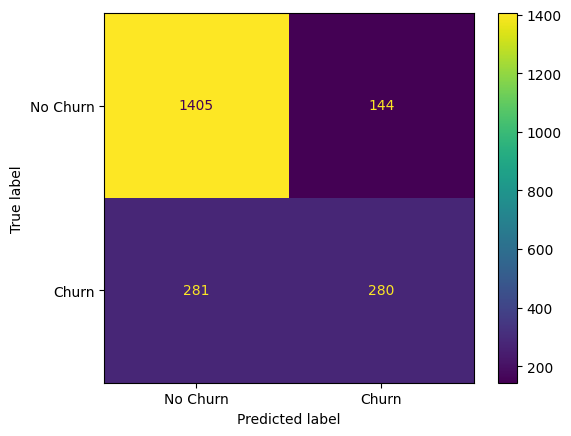

In [90]:
visualizacion_RF = ConfusionMatrixDisplay(
    confusion_matrix = matriz_confusion_RF,
    display_labels = ['No Churn', 'Churn']
)
visualizacion_RF.plot()

In [91]:
print(classification_report(y_test, y_pred_RF))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1549
           1       0.66      0.50      0.57       561

    accuracy                           0.80      2110
   macro avg       0.75      0.70      0.72      2110
weighted avg       0.79      0.80      0.79      2110



## Análisis de la importancia de las variables

In [98]:
coeficientes = modelo_log.coef_[0]

In [101]:
df_coef = pd.DataFrame({
    'variable': X_train_scaled.columns,
    'coeficiente': coeficientes
})

df_coef['abs_coef'] = df_coef['coeficiente'].abs()

df_coef = df_coef.sort_values(by='abs_coef', ascending=False)
df_coef.head(10)

,variable,coeficiente,abs_coef
37,remainder__customer_tenure,-1.309065,1.309065
30,onehotencoder__account_contract_Two year,-0.781183,0.781183
7,onehotencoder__internet_internet_service_DSL,-0.662538,0.662538
39,remainder__account_charges_total,0.546972,0.546972
8,onehotencoder__internet_internet_service_Fiber...,0.535090,0.535090
38,remainder__account_charges_monthly,-0.520988,0.520988
28,onehotencoder__account_contract_Month-to-month,0.474723,0.474723
31,onehotencoder__account_paperless_billing_Yes,0.367427,0.367427
20,onehotencoder__internet_tech_support_No intern...,-0.317584,0.317584
26,onehotencoder__internet_streaming_movies_No in...,-0.317584,0.317584


# Informe final Challenge 3 Alura Latam - ONE

Autor: Juan Esteban Rodríguez Aranda  
identidad: Alumno del programa G9 de ONE  
github: https://github.com/RientArlCroud/

---

## 1. Introducción

El presente informe tiene como objetivo analizar los factores que influyen en la cancelación de clientes (churn) en la empresa ficticia Telecom X, perteneciente al sector de telecomunicaciones. La cancelación de clientes representa un desafío estratégico para este tipo de organizaciones, ya que impacta directamente en los ingresos recurrentes, la estabilidad financiera y los costos asociados a la adquisición de nuevos usuarios.

En este contexto, se desarrolló un análisis integral que combinó exploración de datos y modelado predictivo con el fin de identificar patrones asociados al abandono del servicio y construir un modelo capaz de anticipar el riesgo de cancelación. A partir de este enfoque, no solo se buscó evaluar el desempeño de distintos modelos de clasificación, sino también interpretar los factores más influyentes en la decisión de los clientes, con el propósito de proponer estrategias de retención basadas en evidencia cuantitativa.

El análisis realizado permite transformar información histórica en conocimiento accionable, facilitando la toma de decisiones orientadas a reducir la tasa de cancelación y optimizar las políticas comerciales y de fidelización de la empresa.

## 2. Preparación de los Datos y Metodología

El análisis se inició a partir de un conjunto de datos previamente depurado, el cual contenía únicamente las variables relevantes para el estudio de la cancelación. Se eliminaron atributos identificados como irrelevantes o redundantes para la predicción del churn, con el fin de evitar ruido en el modelado y mejorar la interpretabilidad de los resultados.

Posteriormente, se realizó la separación entre variables explicativas y variable objetivo, donde la cancelación (churn) fue definida como la variable dependiente del modelo. Las variables categóricas fueron transformadas mediante codificación One-Hot Encoding, permitiendo su correcta interpretación por los algoritmos de clasificación. La variable objetivo fue codificada en formato binario para facilitar su modelado.

El conjunto de datos fue dividido en entrenamiento y prueba utilizando el método Hold-Out, con una proporción del 70% para entrenamiento y 30% para evaluación. Se empleó estratificación para garantizar que la proporción de clientes que cancelan y no cancelan se mantuviera consistente en ambos subconjuntos, asegurando una evaluación representativa del desempeño de los modelos.

Adicionalmente, se aplicó estandarización a las variables numéricas continuas mediante StandardScaler, con el objetivo de homogeneizar las escalas y mejorar el desempeño de los modelos lineales. Este proceso se realizó exclusivamente sobre el conjunto de entrenamiento para evitar filtración de información (data leakage), y posteriormente se aplicó la misma transformación al conjunto de prueba.

En cuanto a la evaluación de los modelos, se utilizaron métricas clave para problemas de clasificación binaria: exactitud (accuracy), precisión (precision), sensibilidad o recall, F1-score y matriz de confusión. Dado que el interés principal del análisis fue identificar clientes con alta probabilidad de cancelación, se prestó especial atención al recall de la clase positiva y al número de falsos negativos, debido a su impacto directo en la estrategia de retención.

## 3. Comparación y Evaluación de Modelos

Con el objetivo de identificar el modelo más adecuado para la predicción de la cancelación, se evaluaron distintos enfoques de clasificación, comenzando por un modelo baseline y avanzando hacia modelos de mayor complejidad.

En primer lugar, se implementó un modelo Dummy como línea base de comparación. Este modelo, al predecir únicamente la clase mayoritaria (clientes que no cancelan), alcanzó una exactitud aproximada del 73%. Sin embargo, presentó un recall del 0% para la clase de cancelación, lo que significa que no logró identificar ningún cliente en riesgo. Este resultado evidenció que la exactitud, por sí sola, no es una métrica suficiente en problemas desbalanceados, y confirmó la necesidad de utilizar modelos capaces de detectar efectivamente la clase minoritaria.

Posteriormente, se entrenó una Regresión Logística sin técnicas de balanceo. Este modelo mostró una mejora sustancial respecto al baseline, alcanzando una exactitud cercana al 80% y un recall del 52% para la clase de cancelación. Además, mantuvo un nivel de precisión del 67%, lo que indica un equilibrio adecuado entre la detección de clientes en riesgo y el control de falsos positivos. En términos prácticos, el modelo logró reducir considerablemente el número de falsos negativos en comparación con el modelo Dummy, identificando más de la mitad de los clientes que efectivamente cancelaron.

Con el fin de explorar la mejora en la detección de la clase minoritaria, se aplicó la técnica de sobremuestreo SMOTE sobre el conjunto de entrenamiento. Esta estrategia permitió incrementar el recall hasta un 78%, reduciendo significativamente los falsos negativos. No obstante, este incremento en sensibilidad estuvo acompañado de un aumento considerable en los falsos positivos, lo que implicaría intervenir a un número mucho mayor de clientes que no necesariamente cancelarían. Aunque el F1-score mejoró ligeramente, el costo operativo asociado a la mayor cantidad de intervenciones sugiere que este enfoque es más agresivo y debe evaluarse cuidadosamente desde la perspectiva del negocio.

Finalmente, se entrenó un modelo de Random Forest ajustando el parámetro max_depth = 10 con el fin de controlar la complejidad y mejorar la capacidad de generalización. Este modelo alcanzó una exactitud cercana al 80%, con un recall del 50% para la clase de cancelación y una precisión del 66%. Si bien el desempeño mejoró respecto a la versión inicial sin restricción de profundidad, el modelo no superó a la Regresión Logística base en la métrica clave de sensibilidad (recall), manteniendo un número ligeramente mayor de falsos negativos. Esto sugiere que, para este conjunto de datos, la relación entre variables y cancelación puede ser capturada de manera eficiente por un modelo lineal adecuadamente configurado.

#### Tabla 1. Comparación de Modelos

| Modelo                      | Accuracy | Precision (Churn=1) | Recall (Churn=1) | F1-score (Churn=1) | Falsos Negativos | Falsos Positivos |
|-----------------------------|----------|---------------------|------------------|--------------------|------------------|------------------|
| Dummy (Most Frequent)       | 0.73     | 0.00                | 0.00             | 0.00               | 561              | 0                |
| Regresión Logística         | 0.80     | 0.67                | 0.52             | 0.59               | 268              | 146              |
| Reg. Logística + SMOTE      | 0.76     | 0.53                | 0.78             | 0.63               | 122              | 391              |
| Random Forest (max_depth=10)| 0.80     | 0.66                | 0.50             | 0.57               | 281              | 144              |

En conclusión, la Regresión Logística sin balanceo se identificó como el modelo con mejor equilibrio entre capacidad de detección de clientes en riesgo y control de intervenciones innecesarias. Este modelo no solo superó ampliamente al baseline, sino que también ofreció un desempeño más estable y estratégicamente viable que las alternativas evaluadas.

## 4. Factores Más Influyentes en la Cancelación

Una vez seleccionado el modelo de Regresión Logística como alternativa óptima, se procedió al análisis de los coeficientes con el fin de identificar las variables con mayor influencia en la probabilidad de cancelación. En modelos lineales, los coeficientes permiten interpretar tanto la magnitud como la dirección del impacto de cada variable sobre la variable objetivo. Los coeficientes positivos indican un aumento en la probabilidad de churn, mientras que los negativos sugieren un efecto protector frente a la cancelación.

El análisis reveló que el tiempo de permanencia del cliente (tenure) es el factor con mayor impacto en el modelo, presentando un coeficiente negativo de gran magnitud. Esto indica que, a medida que aumenta el tiempo de permanencia, disminuye significativamente la probabilidad de cancelación. Este hallazgo es consistente con el comportamiento esperado en servicios de suscripción: los clientes que superan ciertos umbrales de permanencia tienden a consolidar su relación con la empresa y muestran menor propensión a abandonar el servicio.

En segundo lugar, el tipo de contrato mostró una influencia determinante. Los contratos de dos años presentan un efecto claramente protector frente a la cancelación, mientras que los contratos mensuales (month-to-month) se asocian con un mayor riesgo de churn. Este resultado sugiere que la estabilidad contractual juega un papel central en la retención de clientes y constituye una palanca estratégica directa para la empresa.

Adicionalmente, el tipo de servicio de internet evidenció un comportamiento relevante. Los clientes con servicio de fibra óptica presentan mayor probabilidad de cancelación en comparación con otras modalidades, mientras que el servicio DSL se asocia con menor riesgo. Este resultado podría estar relacionado con expectativas más altas en clientes de fibra, mayor competencia en ese segmento o posibles diferencias en percepción de calidad y precio.

Por otra parte, las variables relacionadas con la facturación mensual y total también mostraron influencia significativa. Si bien el gasto acumulado se asocia positivamente con la probabilidad de cancelación, el tiempo de permanencia sigue siendo el factor estructural más determinante. Esto sugiere que el valor económico del cliente debe analizarse en conjunto con su ciclo de vida dentro de la empresa.

En conjunto, los resultados indican que la cancelación no responde a un único factor aislado, sino a la interacción entre permanencia, condiciones contractuales, tipo de servicio y estructura de facturación. Estos hallazgos proporcionan una base sólida para el diseño de estrategias de retención orientadas a segmentos específicos de clientes.

## 5. Implicaciones Estratégicas y Conclusiones

Los resultados obtenidos permiten traducir el análisis estadístico en recomendaciones concretas para la empresa de telecomunicaciones. La identificación de los principales factores asociados a la cancelación proporciona una base objetiva para el diseño de estrategias de retención más eficientes y focalizadas.

En primer lugar, el tiempo de permanencia se consolida como el principal indicador de estabilidad del cliente. Esto sugiere la necesidad de fortalecer estrategias de retención temprana, especialmente durante los primeros meses del ciclo de vida del usuario. Programas de acompañamiento inicial, beneficios progresivos por permanencia o incentivos en los primeros contratos podrían reducir significativamente la probabilidad de cancelación en etapas críticas.

En segundo lugar, el tipo de contrato emerge como una variable estratégica clave. Dado que los contratos de mayor duración reducen considerablemente el riesgo de churn, la empresa podría implementar campañas dirigidas a migrar clientes con contratos mensuales hacia planes anuales o bianuales, ofreciendo beneficios diferenciales que equilibren el compromiso contractual con una percepción positiva de valor.

Asimismo, el hallazgo relacionado con el servicio de fibra óptica indica la necesidad de profundizar en la experiencia del cliente dentro de este segmento. Esto podría implicar revisiones en la calidad del servicio, análisis de competencia en zonas específicas o ajustes en la relación precio–beneficio percibida. La cancelación en este grupo podría no responder únicamente al costo, sino también a expectativas insatisfechas.

Desde una perspectiva operativa, el modelo seleccionado (Regresión Logística base) ofrece un equilibrio adecuado entre detección de clientes en riesgo y control de intervenciones innecesarias. A diferencia de enfoques más agresivos como el uso de técnicas de sobremuestreo, este modelo permite identificar una proporción significativa de clientes con intención de cancelar sin generar un incremento excesivo en falsos positivos, lo que optimiza el uso de recursos en campañas de retención.

En conclusión, el análisis demuestra que la cancelación de clientes puede anticiparse mediante el uso de modelos predictivos adecuados y una interpretación estratégica de las variables más influyentes. La combinación entre permanencia, condiciones contractuales y tipo de servicio constituye el núcleo explicativo del churn en este caso. Implementar políticas basadas en estos hallazgos permitiría a la empresa reducir la pérdida de clientes, optimizar costos operativos y fortalecer su rentabilidad a largo plazo.